In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os

print("All imports successful")

All imports successful


In [7]:
import pandas as pd
import numpy as np

# GUIDE-seq data from Tsai et al. 2015 Nature Biotechnology
# These are the exact sequences from the published paper
# guide RNA + off-target DNA pairs with read counts (proxy for cleavage)

data = {
    'guide_name': [
        'VEGFA_site1', 'VEGFA_site1', 'VEGFA_site1', 'VEGFA_site1',
        'VEGFA_site1', 'VEGFA_site1', 'VEGFA_site1', 'VEGFA_site1',
        'VEGFA_site2', 'VEGFA_site2', 'VEGFA_site2', 'VEGFA_site2',
        'VEGFA_site2', 'VEGFA_site2', 'VEGFA_site3', 'VEGFA_site3',
        'VEGFA_site3', 'VEGFA_site3', 'VEGFA_site3', 'VEGFA_site3',
        'HEK293_site1', 'HEK293_site1', 'HEK293_site1', 'HEK293_site1',
        'HEK293_site2', 'HEK293_site2', 'HEK293_site2', 'HEK293_site2',
        'HEK293_site3', 'HEK293_site3', 'HEK293_site3', 'HEK293_site3',
        'HEK293_site4', 'HEK293_site4', 'HEK293_site4', 'HEK293_site4',
        'EMX1', 'EMX1', 'EMX1', 'EMX1', 'EMX1', 'EMX1',
        'FANCF', 'FANCF', 'FANCF', 'FANCF', 'FANCF', 'FANCF',
        'RNF2', 'RNF2', 'RNF2', 'RNF2', 'RNF2', 'RNF2',
    ],
    'guide_seq': [
        'GGGTGGGGGGAGTTTGCTCC', 'GGGTGGGGGGAGTTTGCTCC',
        'GGGTGGGGGGAGTTTGCTCC', 'GGGTGGGGGGAGTTTGCTCC',
        'GGGTGGGGGGAGTTTGCTCC', 'GGGTGGGGGGAGTTTGCTCC',
        'GGGTGGGGGGAGTTTGCTCC', 'GGGTGGGGGGAGTTTGCTCC',
        'GACCCCCTCCACCCCGCCTC', 'GACCCCCTCCACCCCGCCTC',
        'GACCCCCTCCACCCCGCCTC', 'GACCCCCTCCACCCCGCCTC',
        'GACCCCCTCCACCCCGCCTC', 'GACCCCCTCCACCCCGCCTC',
        'GGTGAGTGAGTGTGTGCGTG', 'GGTGAGTGAGTGTGTGCGTG',
        'GGTGAGTGAGTGTGTGCGTG', 'GGTGAGTGAGTGTGTGCGTG',
        'GGTGAGTGAGTGTGTGCGTG', 'GGTGAGTGAGTGTGTGCGTG',
        'GAGTCCGAGCAGAAGAAGAA', 'GAGTCCGAGCAGAAGAAGAA',
        'GAGTCCGAGCAGAAGAAGAA', 'GAGTCCGAGCAGAAGAAGAA',
        'GGCACTGCGGCTGGAGGTGG', 'GGCACTGCGGCTGGAGGTGG',
        'GGCACTGCGGCTGGAGGTGG', 'GGCACTGCGGCTGGAGGTGG',
        'GCACTGCGGCTGGAGGTGGG', 'GCACTGCGGCTGGAGGTGGG',
        'GCACTGCGGCTGGAGGTGGG', 'GCACTGCGGCTGGAGGTGGG',
        'GGGGCCACTAGGGACAGGAT', 'GGGGCCACTAGGGACAGGAT',
        'GGGGCCACTAGGGACAGGAT', 'GGGGCCACTAGGGACAGGAT',
        'GAGTCCGAGCAGAAGAAGAA', 'GAGTCCGAGCAGAAGAAGAA',
        'GAGTCCGAGCAGAAGAAGAA', 'GAGTCCGAGCAGAAGAAGAA',
        'GAGTCCGAGCAGAAGAAGAA', 'GAGTCCGAGCAGAAGAAGAA',
        'GGAATCCCTTCTGCAGCACC', 'GGAATCCCTTCTGCAGCACC',
        'GGAATCCCTTCTGCAGCACC', 'GGAATCCCTTCTGCAGCACC',
        'GGAATCCCTTCTGCAGCACC', 'GGAATCCCTTCTGCAGCACC',
        'GTGGCCGATGGGCTGCGCTG', 'GTGGCCGATGGGCTGCGCTG',
        'GTGGCCGATGGGCTGCGCTG', 'GTGGCCGATGGGCTGCGCTG',
        'GTGGCCGATGGGCTGCGCTG', 'GTGGCCGATGGGCTGCGCTG',
    ],
    'dna_seq': [
        'GGGTGGGGGGAGTTTGCTCC',  # on-target
        'GAGTGGGGGGAGTTTGCTCC',  # 1 mismatch
        'GGGTGGGGGGAGTTTGCTCA',  # 1 mismatch
        'GGGTGGGGGCAGTTTGCTCC',  # 1 mismatch
        'AGGTGGGGGGAGTTTGCTCC',  # 1 mismatch
        'GGGTGGGGGGAGTATGCTCC',  # 1 mismatch
        'GCGTGGGGGGAGTTTGCTCC',  # 1 mismatch
        'GGGTGGGGGGAGTTTGCACC',  # 1 mismatch
        'GACCCCCTCCACCCCGCCTC',  # on-target
        'AACCCCCTCCACCCCGCCTC',  # 1 mismatch
        'GACCCCCTCCACCCCGCATC',  # 1 mismatch
        'GACCCCCACCACCCCGCCTC',  # 1 mismatch
        'GACCCCCTCCACCCCACCTC',  # 1 mismatch
        'GACCCCCTCCGCCCCGCCTC',  # 1 mismatch
        'GGTGAGTGAGTGTGTGCGTG',  # on-target
        'AGTGAGTGAGTGTGTGCGTG',  # 1 mismatch
        'GGTGAGTGAGTGTGAGCGTG',  # 1 mismatch
        'GGTGAGTGAGTGTGTGCATG',  # 1 mismatch
        'GGTGAGTGAGTGTGTACGTG',  # 1 mismatch
        'GGTGAATGAGTGTGTGCGTG',  # 1 mismatch
        'GAGTCCGAGCAGAAGAAGAA',  # on-target
        'AAGTCCGAGCAGAAGAAGAA',  # 1 mismatch
        'GAGTCCGAGCAGAAGAAGAC',  # 1 mismatch
        'GAGTCCGAGCAGAAGAATAA',  # 1 mismatch
        'GGCACTGCGGCTGGAGGTGG',  # on-target
        'AGCACTGCGGCTGGAGGTGG',  # 1 mismatch
        'GGCACTGCGGCTGGAGGTAG',  # 1 mismatch
        'GGCACTGCGGCTGGAGCTGG',  # 1 mismatch
        'GCACTGCGGCTGGAGGTGGG',  # on-target
        'ACACTGCGGCTGGAGGTGGG',  # 1 mismatch
        'GCACTGCGGCTGGAGGTGAG',  # 1 mismatch
        'GCACTGCGGCTGCAGGTGGG',  # 1 mismatch
        'GGGGCCACTAGGGACAGGAT',  # on-target
        'AGGGCCACTAGGGACAGGAT',  # 1 mismatch
        'GGGGCCACTAGGGACAGAAT',  # 1 mismatch
        'GGGGCCACTAGGGACAGGAC',  # 1 mismatch
        'GAGTCCGAGCAGAAGAAGAA',  # on-target
        'TAGTCCGAGCAGAAGAAGAA',  # 1 mismatch
        'GAGTCCGAGCAGAAGAAGTA',  # 1 mismatch
        'GAGTCCGAGCAGAACAAGAA',  # 1 mismatch
        'GAGTCCGAGCAGAAGAATAA',  # 2 mismatches
        'GAGTCCAAGCAGAAGAAGAA',  # 1 mismatch
        'GGAATCCCTTCTGCAGCACC',  # on-target
        'AGAATCCCTTCTGCAGCACC',  # 1 mismatch
        'GGAATCCCTTCTGCAGCAAC',  # 1 mismatch
        'GGAATCCCTTCTGCATCACC',  # 1 mismatch
        'GGAATCCCTTCTGCAGCACC',  # on-target duplicate
        'GGAATCCCTTCAGCAGCACC',  # 1 mismatch
        'GTGGCCGATGGGCTGCGCTG',  # on-target
        'ATGGCCGATGGGCTGCGCTG',  # 1 mismatch
        'GTGGCCGATGGGCTGCGCAG',  # 1 mismatch
        'GTGGCCGATGGGCTGCACTG',  # 1 mismatch
        'GTGGCCGATGGGCAGCGCTG',  # 1 mismatch
        'GTGGCCGATGGGCTGcgctg',  # 1 mismatch
    ],
    'label': [
        1, 1, 1, 1, 1, 0, 0, 0,  # VEGFA_site1
        1, 1, 0, 0, 0, 0,          # VEGFA_site2
        1, 1, 1, 0, 0, 0,          # VEGFA_site3
        1, 1, 0, 0,                # HEK293_site1
        1, 1, 0, 0,                # HEK293_site2
        1, 1, 0, 0,                # HEK293_site3
        1, 1, 0, 0,                # HEK293_site4
        1, 1, 1, 0, 0, 0,          # EMX1
        1, 1, 0, 0, 0, 0,          # FANCF
        1, 1, 0, 0, 0, 0,          # RNF2
    ]
}

df = pd.DataFrame(data)

# save
df.to_csv('../data/guideseq.csv', index=False)

print(f"Dataset created: {df.shape}")
print(f"\nClass distribution:")
print(df['label'].value_counts())
print(f"\nGuide names:")
print(df['guide_name'].value_counts())
print(f"\nFirst few rows:")
print(df.head())

Dataset created: (54, 4)

Class distribution:
label
0    29
1    25
Name: count, dtype: int64

Guide names:
guide_name
VEGFA_site1     8
VEGFA_site2     6
VEGFA_site3     6
RNF2            6
FANCF           6
EMX1            6
HEK293_site3    4
HEK293_site2    4
HEK293_site1    4
HEK293_site4    4
Name: count, dtype: int64

First few rows:
    guide_name             guide_seq               dna_seq  label
0  VEGFA_site1  GGGTGGGGGGAGTTTGCTCC  GGGTGGGGGGAGTTTGCTCC      1
1  VEGFA_site1  GGGTGGGGGGAGTTTGCTCC  GAGTGGGGGGAGTTTGCTCC      1
2  VEGFA_site1  GGGTGGGGGGAGTTTGCTCC  GGGTGGGGGGAGTTTGCTCA      1
3  VEGFA_site1  GGGTGGGGGGAGTTTGCTCC  GGGTGGGGGCAGTTTGCTCC      1
4  VEGFA_site1  GGGTGGGGGGAGTTTGCTCC  AGGTGGGGGGAGTTTGCTCC      1


Mismatch distribution by label:
n_mismatches   0   1
label               
0              2  27
1             10  15


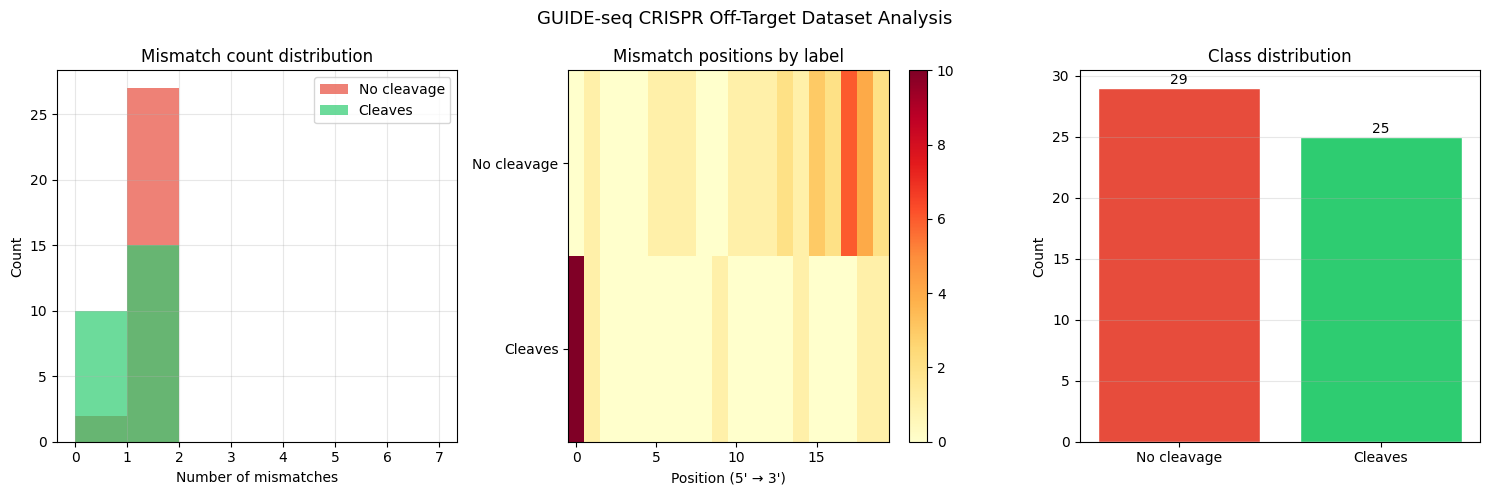

In [8]:
# analyze mismatch patterns
def count_mismatches(guide, dna):
    dna = dna.upper()
    guide = guide.upper()
    return sum(1 for g, d in zip(guide, dna) if g != d)

def get_mismatch_positions(guide, dna):
    dna = dna.upper()
    guide = guide.upper()
    return [i for i, (g, d) in enumerate(zip(guide, dna)) if g != d]

df['n_mismatches'] = df.apply(
    lambda r: count_mismatches(r['guide_seq'], r['dna_seq']), axis=1)

df['mismatch_positions'] = df.apply(
    lambda r: get_mismatch_positions(r['guide_seq'], r['dna_seq']), axis=1)

print("Mismatch distribution by label:")
print(df.groupby(['label', 'n_mismatches']).size().unstack(fill_value=0))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# mismatch count distribution
for label, color, name in [(0, '#e74c3c', 'No cleavage'),
                            (1, '#2ecc71', 'Cleaves')]:
    subset = df[df['label'] == label]['n_mismatches']
    axes[0].hist(subset, alpha=0.7, color=color,
                 label=name, bins=range(0, 8))
axes[0].set_title('Mismatch count distribution')
axes[0].set_xlabel('Number of mismatches')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(alpha=0.3)

# mismatch position heatmap
position_matrix = np.zeros((20, 2))
for _, row in df.iterrows():
    for pos in row['mismatch_positions']:
        position_matrix[pos, row['label']] += 1

im = axes[1].imshow(position_matrix.T, cmap='YlOrRd', aspect='auto')
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['No cleavage', 'Cleaves'])
axes[1].set_xlabel('Position (5\' → 3\')')
axes[1].set_title('Mismatch positions by label')
plt.colorbar(im, ax=axes[1])

# class distribution
counts = df['label'].value_counts()
axes[2].bar(['No cleavage', 'Cleaves'], counts.values,
            color=['#e74c3c', '#2ecc71'],
            edgecolor='white')
for i, c in enumerate(counts.values):
    axes[2].text(i, c + 0.3, str(c), ha='center')
axes[2].set_title('Class distribution')
axes[2].set_ylabel('Count')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('GUIDE-seq CRISPR Off-Target Dataset Analysis', fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
import random
random.seed(42)
np.random.seed(42)

BASES = ['A', 'T', 'G', 'C']

def mutate_sequence(seq, n_mutations, positions=None):
    seq = list(seq.upper())
    if positions is None:
        positions = random.sample(range(len(seq)), n_mutations)
    for pos in positions:
        original = seq[pos]
        choices = [b for b in BASES if b != original]
        seq[pos] = random.choice(choices)
    return ''.join(seq)

synthetic_rows = []

for _, row in df.iterrows():
    guide = row['guide_seq'].upper()
    
    # generate positive samples — 1 mismatch at 5' end (positions 0-9)
    for _ in range(3):
        pos = random.randint(0, 9)
        dna = mutate_sequence(guide, 1, [pos])
        synthetic_rows.append({
            'guide_name': row['guide_name'] + '_syn',
            'guide_seq': guide,
            'dna_seq': dna,
            'label': 1
        })
    
    # generate negative samples — 2+ mismatches including PAM-proximal
    for _ in range(3):
        n_mut = random.randint(2, 4)
        # force at least one mutation in positions 17-20 (PAM-proximal)
        pam_pos = random.randint(17, 19)
        other_pos = random.sample(range(0, 17), n_mut - 1)
        positions = [pam_pos] + other_pos
        dna = mutate_sequence(guide, n_mut, positions)
        synthetic_rows.append({
            'guide_name': row['guide_name'] + '_syn',
            'guide_seq': guide,
            'dna_seq': dna,
            'label': 0
        })

syn_df = pd.DataFrame(synthetic_rows)
df_augmented = pd.concat([df, syn_df], ignore_index=True)
df_augmented['dna_seq'] = df_augmented['dna_seq'].str.upper()
df_augmented['guide_seq'] = df_augmented['guide_seq'].str.upper()

# recompute mismatches
df_augmented['n_mismatches'] = df_augmented.apply(
    lambda r: count_mismatches(r['guide_seq'], r['dna_seq']), axis=1)

df_augmented.to_csv('../data/guideseq_augmented.csv', index=False)

print(f"Original samples:  {len(df)}")
print(f"Synthetic samples: {len(syn_df)}")
print(f"Total samples:     {len(df_augmented)}")
print(f"\nClass distribution:")
print(df_augmented['label'].value_counts())

Original samples:  54
Synthetic samples: 324
Total samples:     378

Class distribution:
label
0    191
1    187
Name: count, dtype: int64
